# Binary Classification with a Software Defects Dataset - Yazılım Hataları Veri Kümesi ile İkili Sınıflandırma

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQwEwwiojW3iV0FsT4XBrlRAS3hBFI5bWK85A&s">

Bu projede, yazılım modüllerine ait çeşitli metrikler kullanılarak bir modülde hata (defect) bulunup bulunmadığının tahmin edilmesi amaçlanmıştır. Veri seti üzerinde gerekli ön işleme adımları uygulanmış, eksik ve kategorik veriler düzenlenerek makine öğrenmesi algoritmaları için uygun hale getirilmiştir. Ardından farklı sınıflandırma modelleri eğitilmiş ve modellerin performansları Accuracy, Precision, Recall ve F1 Score gibi metrikler kullanılarak karşılaştırılarak en başarılı model belirlenmiştir.

### Sütun Açıklamaları

**id**: Her satır için benzersiz kimlik numarasıdır. Model eğitiminde genellikle kullanılmaz.

**loc**: Kod satırı sayısını ifade eder.

**v(g)**: McCabe çevrimsel karmaşıklık değeridir.

**ev(g)**: Temel karmaşıklık değeridir.

**iv(g)**: Tasarım karmaşıklığı değeridir.

**n**: Programdaki toplam operatör ve operand sayısını ifade eder.

**v**: Halstead hacim metriğidir.

**l**: Program uzunluğu / seviye metriğidir.

**d**: Program zorluk metriğidir.

**i**: Program zekâ / bilgi içeriği metriğidir.

**e**: Program efor metriğidir.

**b**: Tahmini hata sayısı metriğidir.

**t**: Programlama süresi metriğidir.

**lOCode**: Kod satırı sayısını ifade eden ölçümdür.

**lOComment**: Yorum satırı sayısını ifade eder.

**lOBlank**: Boş satır sayısını ifade eder.

**locCodeAndComment**: Hem kod hem yorum içeren satır sayısını ifade eder.

**uniq_Op**: Benzersiz operatör sayısını ifade eder.

**uniq_Opnd**: Benzersiz operand sayısını ifade eder.

**total_Op**: Toplam operatör sayısını ifade eder.

**total_Opnd**: Toplam operand sayısını ifade eder.

**branchCount**: Kod içerisindeki dallanma sayısını ifade eder.

**defects**: Hedef değişkendir. Yazılım modülünde hata olup olmadığını gösterir.

### Veri seti linki

https://www.kaggle.com/competitions/playground-series-s3e23

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s3e23/sample_submission.csv
/kaggle/input/competitions/playground-series-s3e23/train.csv
/kaggle/input/competitions/playground-series-s3e23/test.csv


In [2]:
# ==========================================
# Veri Analizi
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# Görselleştirme
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Uyarıları Kapatma
# ==========================================
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Ön İşleme
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# Modeller
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB

# ==========================================
# Değerlendirme Metrikleri
# ==========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# Çapraz Doğrulama (İsteğe Bağlı)
# ==========================================
from sklearn.model_selection import cross_val_score# ==========================================
# Veri Analizi
# ==========================================
import pandas as pd
import numpy as np

# ==========================================
# Görselleştirme
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Uyarıları Kapatma
# ==========================================
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# Ön İşleme
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ==========================================
# Modeller
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB

# ==========================================
# Değerlendirme Metrikleri
# ==========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# Çapraz Doğrulama (İsteğe Bağlı)
# ==========================================
from sklearn.model_selection import cross_val_score

In [3]:
# Train ve test veri setlerini oku
train = pd.read_csv("/kaggle/input/competitions/playground-series-s3e23/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s3e23/test.csv")

# İlk 5 satırı görüntüle
train.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,0,22.0,3.0,1.0,2.0,60.0,278.63,0.06,19.56,14.25,...,17,1,1,0,16.0,9.0,38.0,22.0,5.0,False
1,1,14.0,2.0,1.0,2.0,32.0,151.27,0.14,7.00,21.11,...,11,0,1,0,11.0,11.0,18.0,14.0,3.0,False
2,2,11.0,2.0,1.0,2.0,45.0,197.65,0.11,8.05,22.76,...,8,0,1,0,12.0,11.0,28.0,17.0,3.0,False
3,3,8.0,1.0,1.0,1.0,23.0,94.01,0.19,5.25,17.86,...,4,0,2,0,8.0,6.0,16.0,7.0,1.0,True
4,4,11.0,2.0,1.0,2.0,17.0,60.94,0.18,5.63,12.44,...,7,0,2,0,7.0,6.0,10.0,10.0,3.0,False


In [4]:
print(train.shape)
print(test.shape)


(101763, 23)
(67842, 22)


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101763 entries, 0 to 101762
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 101763 non-null  int64  
 1   loc                101763 non-null  float64
 2   v(g)               101763 non-null  float64
 3   ev(g)              101763 non-null  float64
 4   iv(g)              101763 non-null  float64
 5   n                  101763 non-null  float64
 6   v                  101763 non-null  float64
 7   l                  101763 non-null  float64
 8   d                  101763 non-null  float64
 9   i                  101763 non-null  float64
 10  e                  101763 non-null  float64
 11  b                  101763 non-null  float64
 12  t                  101763 non-null  float64
 13  lOCode             101763 non-null  int64  
 14  lOComment          101763 non-null  int64  
 15  lOBlank            101763 non-null  int64  
 16  lo

In [6]:
train.describe()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
count,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,...,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000
mean,50881.000000,37.347160,5.492684,2.845022,3.498826,96.655995,538.280956,0.111634,13.681881,27.573007,...,1141.357982,22.802453,1.773945,3.979865,0.196604,11.896131,15.596671,57.628116,39.249698,9.839549
std,29376.592059,54.600401,7.900855,4.631262,5.534541,171.147191,1270.791601,0.100096,14.121306,22.856742,...,9862.795472,38.541010,5.902412,6.382358,0.998906,6.749549,18.064261,104.537660,71.692309,14.412769
min,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25440.500000,13.000000,2.000000,1.000000,1.000000,25.000000,97.670000,0.050000,5.600000,15.560000,...,31.380000,7.000000,0.000000,1.000000,0.000000,8.000000,7.000000,15.000000,10.000000,3.000000
50%,50881.000000,22.000000,3.000000,1.000000,2.000000,51.000000,232.790000,0.090000,9.820000,23.360000,...,125.400000,14.000000,0.000000,2.000000,0.000000,11.000000,12.000000,30.000000,20.000000,5.000000
75%,76321.500000,42.000000,6.000000,3.000000,4.000000,111.000000,560.250000,0.150000,18.000000,34.340000,...,565.920000,26.000000,1.000000,5.000000,0.000000,16.000000,20.000000,66.000000,45.000000,11.000000
max,101762.000000,3442.000000,404.000000,165.000000,402.000000,8441.000000,80843.080000,1.000000,418.200000,569.780000,...,935923.390000,2824.000000,344.000000,219.000000,43.000000,410.000000,1026.000000,5420.000000,3021.000000,503.000000


In [7]:
train.isnull().sum()

id                   0
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64

In [8]:
train.nunique()

id                   101763
loc                     378
v(g)                    106
ev(g)                    71
iv(g)                    84
n                       836
v                      4515
l                        55
d                      3360
i                      5171
e                      8729
b                       315
t                      8608
lOCode                  298
lOComment                91
lOBlank                  94
locCodeAndComment        29
uniq_Op                  70
uniq_Opnd               176
total_Op                623
total_Opnd              485
branchCount             144
defects                   2
dtype: int64

In [9]:
train.columns

Index(['id', 'loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e',
       'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment',
       'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount',
       'defects'],
      dtype='object')

In [10]:
# id sütununu kaldır
train.drop(columns=["id"], inplace=True)
test.drop(columns=["id"], inplace=True)

In [11]:
# Hedef değişkeni sayısallaştır
print(train["defects"].unique())

[False  True]


In [12]:
target_mapping = {
    False: 0,
    True: 1
}

train["defects"] = train["defects"].map(target_mapping)

train["defects"].head()

0    0
1    0
2    0
3    1
4    0
Name: defects, dtype: int64

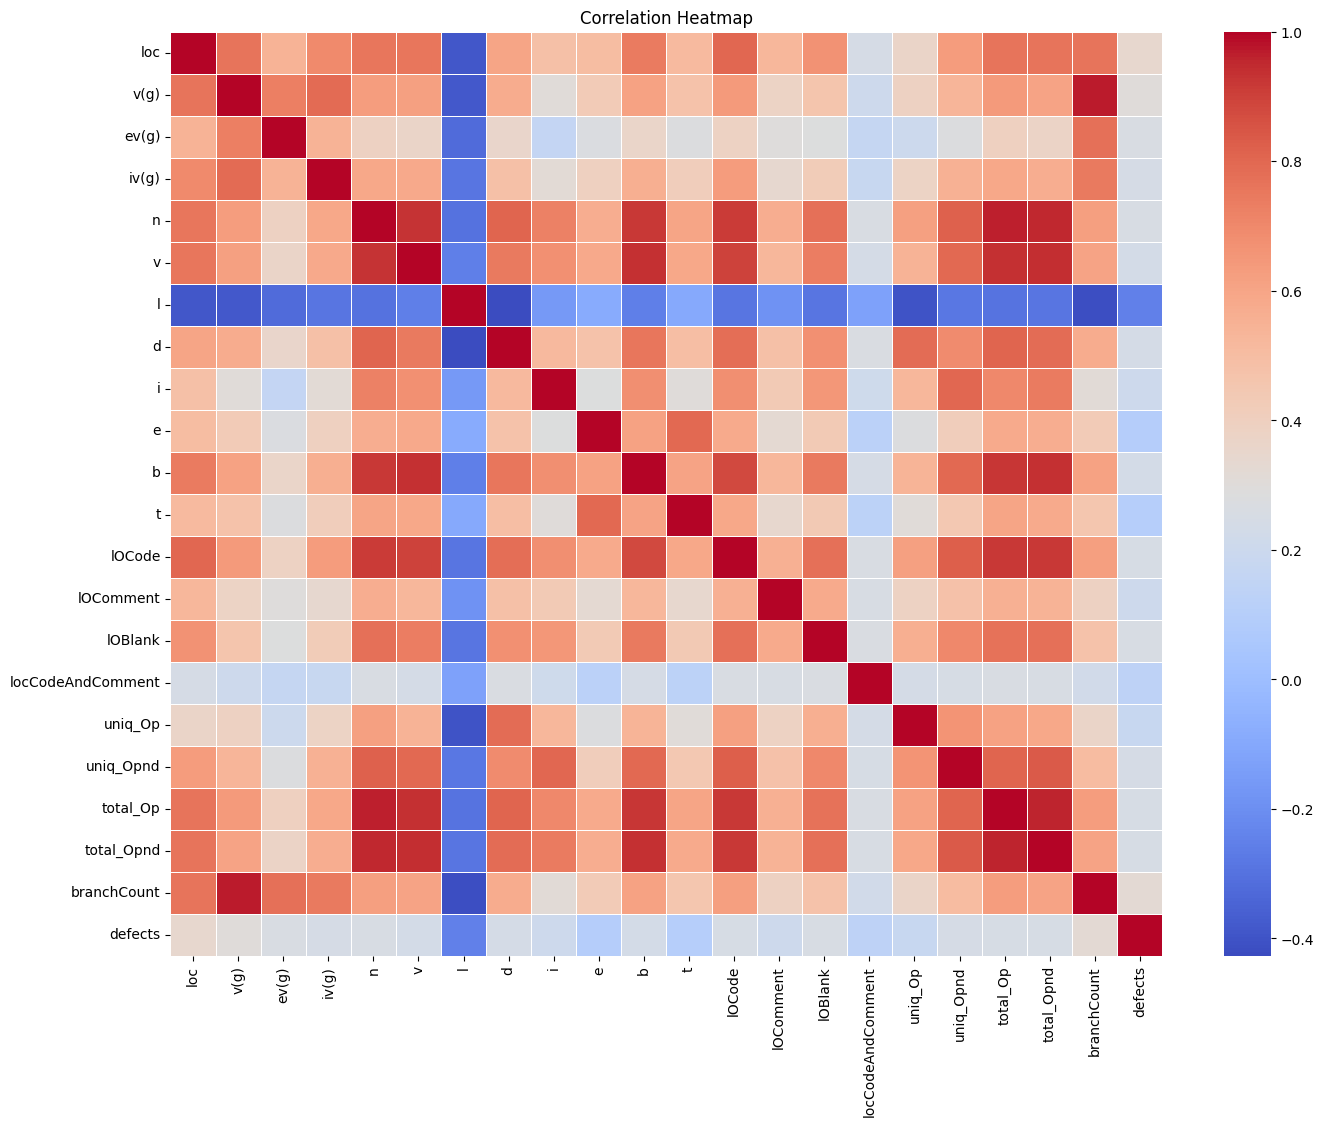

In [13]:
plt.figure(figsize=(16,12))

sns.heatmap(
    train.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Isı haritası incelendiğinde, veri setindeki bazı değişkenler arasında orta ve yüksek düzeyde pozitif korelasyonlar bulunduğu görülmektedir. Özellikle Halstead metrikleri (n, v, e, b, total_Op, total_Opnd ve branchCount) birbirleriyle güçlü pozitif ilişki göstermektedir. Buna karşılık l (program seviyesi) değişkeni birçok özellik ile negatif korelasyona sahiptir. Hedef değişken olan defects sütununun diğer değişkenlerle olan korelasyonlarının genel olarak düşük seviyede olduğu görülmektedir. Bu durum, yazılım hatalarının tek bir değişken yerine birçok özelliğin birlikte değerlendirilmesiyle daha doğru tahmin edilebileceğini göstermektedir. Genel olarak veri setinde anlamlı ilişkiler bulunmakla birlikte, tek başına hedef değişkeni güçlü şekilde açıklayan bir özellik bulunmamaktadır. Bu nedenle, değişkenler arasındaki karmaşık ilişkileri öğrenebilen makine öğrenmesi algoritmalarının kullanılması daha uygun bir yaklaşım olacaktır.

In [14]:
# Bağımsız değişkenler
x = train.drop("defects", axis=1)

# Hedef değişken
y = train["defects"]

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.8085294551171818


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

y_pred_dt = dt_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.7156193190193092


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(x_train, y_train)

y_pred_lr = lr_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.7935439492949442


In [19]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

et_model = ExtraTreesClassifier(random_state=42)

et_model.fit(x_train, y_train)

y_pred_et = et_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_et))

Accuracy: 0.8057288851766324


In [20]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train, y_train)

y_pred_gb = gb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))

Accuracy: 0.8139340637743822


In [21]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

nb_model = GaussianNB()

nb_model.fit(x_train, y_train)

y_pred_nb = nb_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.7981133002505774


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd

def algo_test(x, y):

    LR = LogisticRegression(max_iter=1000)
    DT = DecisionTreeClassifier(random_state=42)
    RF = RandomForestClassifier(random_state=42, n_jobs=-1)
    ET = ExtraTreesClassifier(random_state=42, n_jobs=-1)
    GB = GradientBoostingClassifier(random_state=42)
    NB = GaussianNB()

    algos = [LR, DT, RF, ET, GB, NB]

    algo_names = [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "Naive Bayes"
    ]

    x_train, x_test, y_train, y_test = train_test_split(
        x,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    accuracy = []
    precision = []
    recall = []
    f1 = []
    roc_auc = []

    result = pd.DataFrame(
        columns=[
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        index=algo_names
    )

    for algo in algos:

        algo.fit(x_train, y_train)

        p = algo.predict(x_test)

        proba = algo.predict_proba(x_test)[:, 1]

        accuracy.append(accuracy_score(y_test, p))
        precision.append(precision_score(y_test, p))
        recall.append(recall_score(y_test, p))
        f1.append(f1_score(y_test, p))
        roc_auc.append(roc_auc_score(y_test, proba))

    result["Accuracy"] = accuracy
    result["Precision"] = precision
    result["Recall"] = recall
    result["F1 Score"] = f1
    result["ROC-AUC"] = roc_auc

    return result.sort_values(
        "ROC-AUC",
        ascending=False
    )

In [26]:
algo_test(x, y)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Gradient Boosting,0.813934,0.652286,0.383481,0.483003,0.792415
Random Forest,0.808529,0.635196,0.364622,0.463297,0.773945
Naive Bayes,0.798113,0.660305,0.225016,0.335651,0.771556
Extra Trees,0.805729,0.623640,0.360286,0.456719,0.766873
Logistic Regression,0.793544,0.582497,0.314546,0.408502,0.700712
Decision Tree,0.715619,0.382758,0.415781,0.398587,0.609638


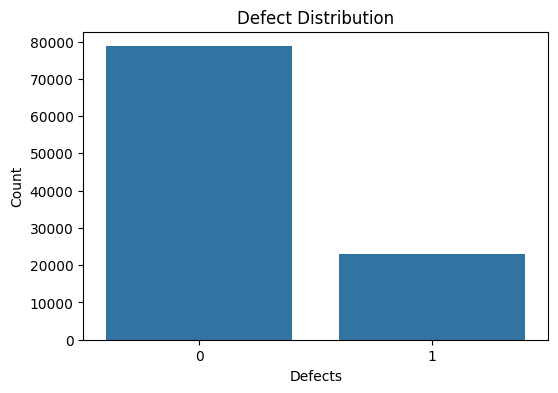

In [27]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="defects",
    data=train
)

plt.title("Defect Distribution")
plt.xlabel("Defects")
plt.ylabel("Count")

plt.show()

## Sonuç

Model performansları incelendiğinde Accuracy değerlerinin yüksek olmasına rağmen Precision, Recall ve F1 Score değerlerinin görece daha düşük olduğu görülmektedir. Bunun temel nedeni, veri setinde hata bulunmayan (0) sınıfının hata bulunan (1) sınıfına göre belirgin şekilde daha fazla olmasıdır. Bu sınıf dengesizliği nedeniyle modeller çoğunluk sınıfını daha başarılı tahmin ederken, azınlık sınıfını temsil eden hatalı yazılım modüllerini tespit etmekte zorlanmaktadır. Bu durum özellikle Recall ve F1 Score değerlerinin düşmesine neden olmuş, yalnızca Accuracy değerinin model performansını değerlendirmek için yeterli olmadığını göstermiştir. Bu nedenle modeller ROC-AUC, Precision, Recall ve F1 Score metrikleri birlikte değerlendirilmiştir.